In [209]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv', encoding='latin-1')

## 1. Data Loading and Exploration

In [210]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
...,...,...,...,...,...,...,...
10603,23/01/2023,138.119995,143.320007,137.899994,141.110001,141.110001,81760300
10604,24/01/2023,140.309998,143.160004,140.300003,142.529999,142.529999,66435100
10605,25/01/2023,140.889999,142.429993,138.809998,141.860001,141.860001,65799300
10606,26/01/2023,143.169998,144.250000,141.899994,143.960007,143.960007,54105100


In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


Date is a string, we must change it to a datetime

In [212]:
df["Date"] = pd.to_datetime(df["Date"], format='mixed')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[us]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 580.3 KB


In [213]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,10608,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,2002-01-06 12:55:06.787330,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
min,1981-01-04 00:00:00,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,1991-06-30 06:00:00,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,2002-01-02 12:00:00,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,2012-07-16 06:00:00,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,2023-12-01 00:00:00,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09
std,NaN,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


Time Series and Frequancies Analysis:

In [214]:
df["Date"].diff().value_counts()

Date
1 days       4776
31 days      1646
30 days      1115
3 days        992
92 days       344
             ... 
-173 days       2
123 days        2
-22 days        1
5 days          1
-53 days        1
Name: count, Length: 84, dtype: int64

We can see negative values

In [215]:
df["Date"].is_monotonic_increasing

False

Confirmation here: we must sort the datas before going further

In [216]:
df = df.sort_values("Date").reset_index(drop=True)
df["Date"].is_monotonic_increasing

True

## 2. Data Visualization

For a better datas visualisation, we group datas by year 

In [217]:
df_year = df.drop(columns="Date").groupby(df["Date"].dt.year).mean()
df_year

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981,0.108883,0.109265,0.108548,0.108548,0.084466,3.239899e+07
1982,0.085446,0.086665,0.084630,0.085459,0.066500,8.444667e+07
1983,0.167274,0.171085,0.163449,0.167274,0.130164,1.759408e+08
1984,0.119956,0.122294,0.117642,0.119651,0.093106,1.659250e+08
1985,0.091057,0.092023,0.089937,0.090233,0.070215,1.805249e+08
1986,0.144586,0.147048,0.142207,0.144913,0.112764,2.107637e+08
1987,0.347817,0.355806,0.339820,0.347751,0.271125,2.362502e+08
1988,0.371034,0.376663,0.365092,0.370884,0.291198,1.632134e+08
1989,0.371563,0.377679,0.365881,0.371953,0.294826,2.020072e+08


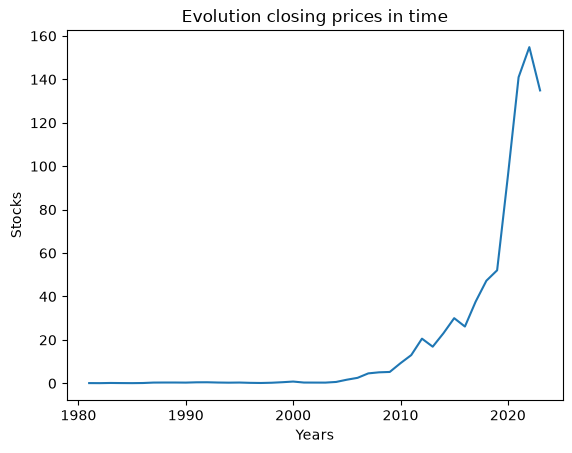

In [218]:
df_year_close = df_year['Close']

plt.plot(df_year_close.index, df_year_close.values)
plt.xlabel("Years")
plt.ylabel("Stocks")
plt.title("Evolution closing prices in time")
plt.show()

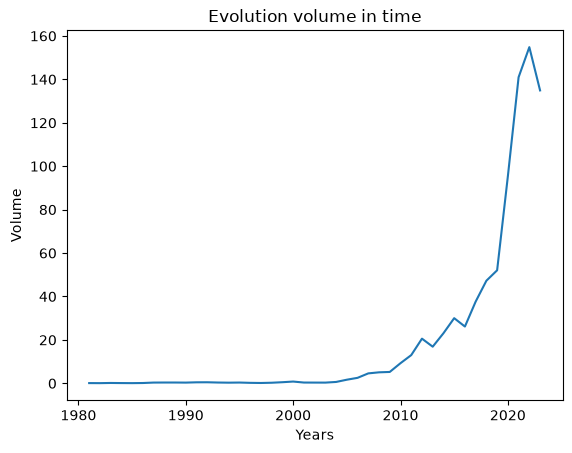

In [219]:
df_year_volume = df_year['Volume']

plt.plot(df_year_volume.index, df_year_close.values)
plt.xlabel("Years")
plt.ylabel("Volume")
plt.title("Evolution volume in time")
plt.show()

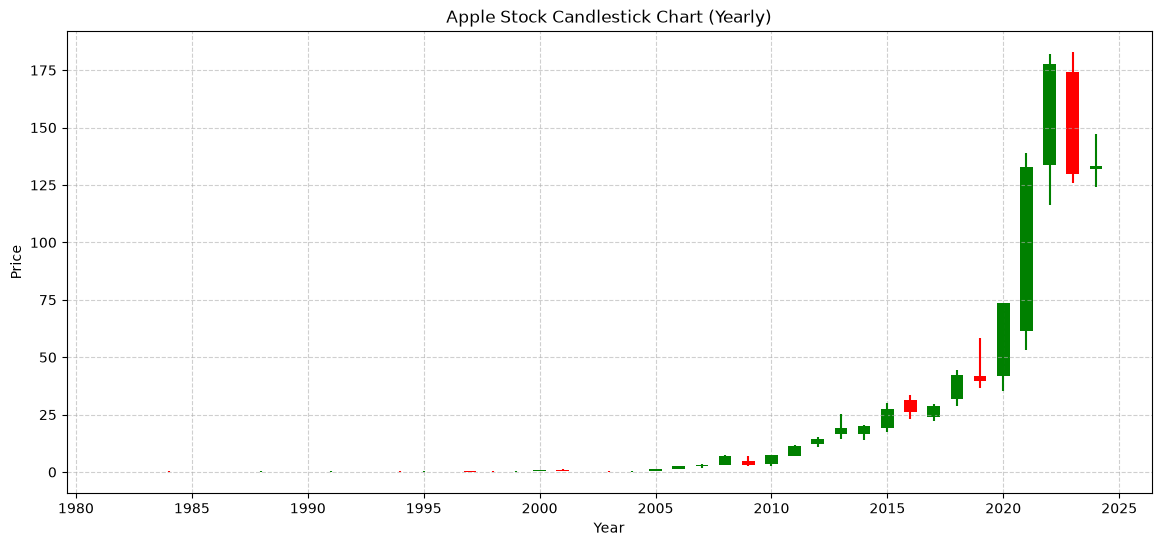

In [220]:
df_candle = df.set_index("Date")[["Open", "High", "Low", "Close"]]
df_candle = df_candle.resample("YE").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last"
})

fig, ax = plt.subplots(figsize=(14, 6))

colors = df_candle.apply(lambda row: "green" if row["Close"] >= row["Open"] else "red", axis=1)
height=(df_candle["Close"] - df_candle["Open"]).abs()
bottom=df_candle[["Open", "Close"]].min(axis=1)
ax.vlines(df_candle.index, df_candle["Low"], df_candle["High"], color=colors)

ax.bar(df_candle.index,
       height=(df_candle["Close"] - df_candle["Open"]).abs(),
       bottom=df_candle[["Open", "Close"]].min(axis=1),
       color=colors, width=200)

ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("Year")
ax.set_ylabel("Price")
ax.set_title("Apple Stock Candlestick Chart (Yearly)")
plt.show()

## 3. Statistical Analysis

All the stats by year for each columns

In [221]:
cols = df.columns.tolist()
cols.pop(0)  # retire "Date"

for col in cols:
    df_stat = df.groupby(df["Date"].dt.year)[col].agg([
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
    ])
    print(f"\n*** {col} ***")
    print(df_stat)


*** Open ***
            mean      median        std         min         max
Date                                                           
1981    0.108883    0.111049   0.021831    0.064174    0.154018
1982    0.085446    0.079799   0.026687    0.049665    0.151228
1983    0.167274    0.172991   0.054684    0.079799    0.280134
1984    0.119956    0.118862   0.009464    0.101004    0.148438
1985    0.091057    0.088170   0.020420    0.065290    0.136719
1986    0.144586    0.149554   0.024725    0.098214    0.194754
1987    0.347817    0.343750   0.076883    0.180246    0.531250
1988    0.371034    0.368304   0.022420    0.319196    0.420759
1989    0.371563    0.376116   0.036650    0.301339    0.444196
1990    0.334839    0.339286   0.040937    0.225446    0.424107
1991    0.468318    0.455357   0.062809    0.366071    0.647321
1992    0.489318    0.504464   0.067111    0.375000    0.625000
1993    0.366636    0.345982   0.117782    0.202009    0.571429
1994    0.304040    0.3041

The stats for each columns

In [222]:
cols = df.columns.tolist()
cols.pop(0)  # retire "Date"

df[cols].agg(['mean', 'median', 'std', 'min', 'max'])

,Open,High,Low,Close,Adj Close,Volume
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
median,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


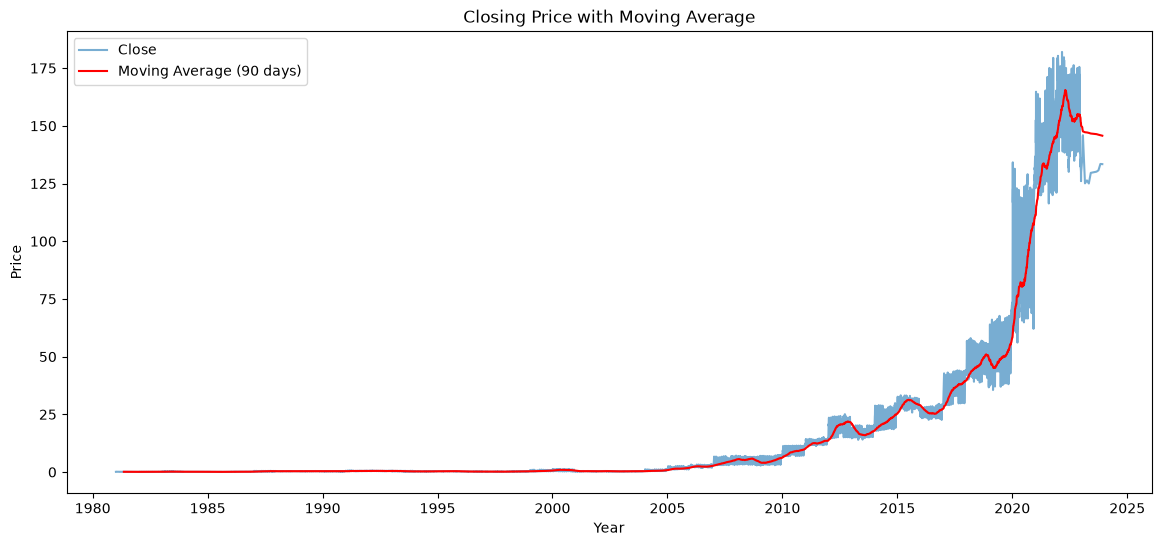

In [250]:
df["Close_90"] = df["Close"].rolling(window=90).mean()

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
plt.plot(df["Date"], df["Close_90"], label="Moving Average (90 days)", color="red")
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Closing Price with Moving Average")
plt.legend()
plt.show()

We smoth the graph by doing a meaning for 90 days.
The graph here is more readable.

## 4. Hypothesis Testing

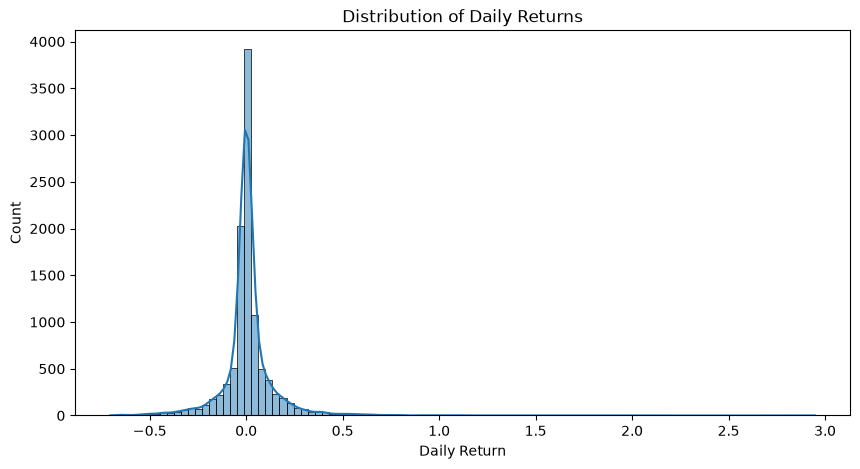

Statistic: 9363.82
p-value: 0.00e+00
We reject H0: daily returns are not normally distributed.


In [ ]:
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(df["Daily_Return"].dropna(), bins=100, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

stat, p_value = stats.normaltest(df["Daily_Return"].dropna())
print(f"Statistic: {stat:.2f}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("We reject H0: daily returns are not normally distributed.")
else:
    print("We fail to reject H0: daily returns appear normally distributed.")

## 5. Advanced Statistical Techniques (Bonus)

In [265]:
window = 30
weights = np.ones(window) / window

close_ma = np.convolve(df["Close"], weights, mode="valid")
volume_ma = np.convolve(df["Volume"], weights, mode="valid")

correlation = np.corrcoef(close_ma, volume_ma)[0, 1]
print(f"Correlation between Close MA and Volume MA: {correlation:.2f}")

Correlation between Close MA and Volume MA: -0.28


The correlation coefficient of -0.28 indicates a weak-to-moderate negative relationship between the moving averages of closing price and trading volume: as the stock price trended upward over time, trading volume tended to decline slightly. However, the relationship is not strong, so volume trends can't be reliably predicted from price trends alone.

## 6. Summary and Insights

## 7. Reflection